In [90]:
!pip install ucimlrepo
import pandas as pd


In [91]:
from ucimlrepo import fetch_ucirepo
phiusiil = fetch_ucirepo(id=967)

x = phiusiil.data.features
y = phiusiil.data.targets

df = pd.concat([x, y], axis=1)

print(df.shape)
print(df.columns.tolist())


(235795, 55)
['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [92]:
print(df.iloc[:, -1].value_counts())


label
1    134850
0    100945
Name: count, dtype: int64


In [93]:
df.to_csv("phisiil_raw.csv", index=False)
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [94]:
url_col = "URL"
label_col = df.columns[-1]
print("Exact duplicate URLs:", df[url_col].duplicated().sum())
df_clean = df.drop_duplicates(subset=url_col).reset_index(drop=True)
print("Rows after dedup:", len(df_clean))

Exact duplicate URLs: 425
Rows after dedup: 235370


In [95]:
import re
def has_path_or_query(url):
  after_scheme = re.sub(r'^https?://','', str(url))
  parts = after_scheme.split('/', 1)
  if len(parts) < 2:
    return False
  rest = parts[1]
  return len(rest.strip('/')) > 0 or '?' in str(url)
def starts_with_www(url):
  after_scheme = re.sub(r'^https?://', '', str(url))
  return after_scheme.startswith('www.')

def is_https(url):
    return str(url).startswith('https://')

df_clean['has_path'] = df_clean[url_col].apply(has_path_or_query)
df_clean['starts_www'] = df_clean[url_col].apply(starts_with_www)
df_clean['is_https'] = df_clean[url_col].apply(is_https)
print("Share of URLs WITH a path/query, by label:")
print(df_clean.groupby(label_col)['has_path'].mean())

print("\nShare of URLs starting with 'www.', by label:")
print(df_clean.groupby(label_col)['starts_www'].mean())

print("\nShare of URLs using HTTPS, by label:")
print(df_clean.groupby(label_col)['is_https'].mean())





Share of URLs WITH a path/query, by label:
label
0    0.283585
1    0.000000
Name: has_path, dtype: float64

Share of URLs starting with 'www.', by label:
label
0    0.415042
1    1.000000
Name: starts_www, dtype: float64

Share of URLs using HTTPS, by label:
label
0    0.486321
1    1.000000
Name: is_https, dtype: float64


In [96]:
print("Examples the function thinks DO have a path:")
print(df_clean.loc[df_clean['has_path'] == True, url_col].head(5).to_string())

print("\nExamples the function thinks DON'T have a path:")
print(df_clean.loc[df_clean['has_path'] == False, url_col].head(5).to_string())

Examples the function thinks DO have a path:
31    https://ipfs.io/ipfs/qmrvvyr84esa2assw9vvwupqj...
45    https://pontosapontamentolu.com/gclid/=/c/?gcl...
57                https://topaka.cloud/ob52gtplj/18snwp
77    https://s3.amazonaws.com/appforest_uf/f1678949...
91    http://tkmowpikuk.owl4fsrch.club/vnafvra97w/?q...

Examples the function thinks DON'T have a path:
0      https://www.southbankmosaics.com
1              https://www.uni-mainz.de
2        https://www.voicefmradio.co.uk
3           https://www.sfnmjournal.com
4    https://www.rewildingargentina.org


In [97]:
audit_findings = {
    "total_rows": len(df_clean),
    "duplicates_removed": 425,
    "homepage_only_bias": {
        "phishing_pct_with_path": 28.4,
        "legitimate_pct_with_path": 0.0
    },
    "www_prefix_bias": {"phishing_pct": 41.5, "legitimate_pct": 100.0},
    "https_bias": {"phishing_pct": 48.6, "legitimate_pct": 100.0}
}
import json
with open("phase0_audit_findings.json", "w") as f:
    json.dump(audit_findings, f, indent=2)
print("Saved.")

Saved.


Data audit: checking for hidden bias

Before training any model, I checked whether the legitimate and phishing URLs might differ from each other in a trivial way that has nothing to do with real phishing. I found that 100% of legitimate URLs are bare homepages using "www." and HTTPS, while phishing URLs are a real mix. This means a model could learn a lazy, wrong shortcut ("anything with a path is phishing") instead of real phishing patterns — I'll need to account for this in Phase 2 (either through feature choices or by testing the model on real deep-link URLs afterward).

In [98]:
df_clean.to_csv("for_viewing.csv")

In [99]:
!pip install tldextract
import tldextract

# quick test on tricky multi-part cases
test_urls = ["https://mail.example.co.uk/login", "https://shop.example.com.au", "https://docs.google.com"]
for u in test_urls:
    ext = tldextract.extract(u)
    print(u, "->", f"{ext.domain}.{ext.suffix}")

https://mail.example.co.uk/login -> example.co.uk
https://shop.example.com.au -> example.com.au
https://docs.google.com -> google.com


In [100]:
def get_registrable_domain(url):
    ext = tldextract.extract(str(url))
    return f"{ext.domain}.{ext.suffix}"

df_clean['registrable_domain'] = df_clean[url_col].apply(get_registrable_domain)

print("Total rows:", len(df_clean))
print("Unique websites (registrable domains):", df_clean['registrable_domain'].nunique())
df_clean[[url_col, 'registrable_domain']].head(10)

Total rows: 235370
Unique websites (registrable domains): 175509


,URL,registrable_domain
0,https://www.southbankmosaics.com,southbankmosaics.com
1,https://www.uni-mainz.de,uni-mainz.de
2,https://www.voicefmradio.co.uk,voicefmradio.co.uk
3,https://www.sfnmjournal.com,sfnmjournal.com
4,https://www.rewildingargentina.org,rewildingargentina.org
5,https://www.globalreporting.org,globalreporting.org
6,https://www.saffronart.com,saffronart.com
7,https://www.nerdscandy.com,nerdscandy.com
8,https://www.hyderabadonline.in,hyderabadonline.in
9,https://www.aap.org,aap.org


In [101]:
from sklearn.model_selection import train_test_split
domain_labels = df_clean.groupby('registrable_domain')[label_col].agg(lambda x: x.mode()[0]).reset_index()
domain_labels.columns = ['registrable_domain', 'majority_label']
print("Number of unique websites:", len(domain_labels))
print(domain_labels['majority_label'].value_counts())

Number of unique websites: 175509
majority_label
1    132006
0     43503
Name: count, dtype: int64


In [102]:
train_domains, temp_domains = train_test_split(
    domain_labels,
    test_size=0.30,
    stratify=domain_labels['majority_label'],
    random_state=42
)
val_domains, test_domains = train_test_split(
    temp_domains,
    test_size=0.50,
    stratify=temp_domains['majority_label'],
    random_state=42
)
print("Train websites:", len(train_domains))
print("Val websites:", len(val_domains))
print("Test websites:", len(test_domains))


Train websites: 122856
Val websites: 26326
Test websites: 26327


In [103]:
domain_to_split = {}
for d in train_domains['registrable_domain']:
    domain_to_split[d] = 'train'
for d in val_domains['registrable_domain']:
    domain_to_split[d] = 'val'
for d in test_domains['registrable_domain']:
    domain_to_split[d] = 'test'

# now just look each row's domain up in that dictionary — fast
df_clean['split'] = df_clean['registrable_domain'].map(domain_to_split)

print(df_clean['split'].value_counts())
print("\nClass balance (legitimate share) within each split:")
print(df_clean.groupby('split')[label_col].mean())

split
train    165033
val       36755
test      33582
Name: count, dtype: int64

Class balance (legitimate share) within each split:
split
test     0.601215
train    0.571631
val      0.552904
Name: label, dtype: float64


In [104]:
leak_check = df_clean.groupby('registrable_domain')['split'].nunique()
print("Websites appearing in more than one split:", (leak_check > 1).sum())

Websites appearing in more than one split: 0


In [105]:
import numpy as np
from collections import Counter
def domain_entropy(domain):
  if len(domain) == 0:
        return 0
  counts = Counter(domain)
  probs = [c / len(domain) for c in counts.values()]
  return -sum(p * np.log2(p) for p in probs)
def extract_domain_features(url):
    ext = tldextract.extract(str(url))
    full_domain = ".".join([p for p in [ext.subdomain, ext.domain, ext.suffix] if p])


    return {
        "domain_length": len(full_domain),
        "num_subdomains": ext.subdomain.count('.') + 1 if ext.subdomain else 0,
        "has_ip_host": 1 if re.match(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$', ext.domain) else 0,
        "has_punycode": 1 if "xn--" in full_domain else 0,
        "tld_length": len(ext.suffix),
        "domain_entropy": domain_entropy(ext.domain),
        "is_https": 1 if str(url).startswith("https://") else 0,
        "has_at_symbol": 1 if "@" in str(url) else 0,
        "has_port": 1 if re.search(r':\d+', full_domain) else 0,
    } # this is always 0 since tldextract strips the port, so this features carries no signal(kept so results stay reproducible)
for u in df_clean[url_col].head(5):
    print(u, "->", extract_domain_features(u))


https://www.southbankmosaics.com -> {'domain_length': 24, 'num_subdomains': 1, 'has_ip_host': 0, 'has_punycode': 0, 'tld_length': 3, 'domain_entropy': np.float64(3.452819531114783), 'is_https': 1, 'has_at_symbol': 0, 'has_port': 0}
https://www.uni-mainz.de -> {'domain_length': 16, 'num_subdomains': 1, 'has_ip_host': 0, 'has_punycode': 0, 'tld_length': 2, 'domain_entropy': np.float64(2.725480556997868), 'is_https': 1, 'has_at_symbol': 0, 'has_port': 0}
https://www.voicefmradio.co.uk -> {'domain_length': 22, 'num_subdomains': 1, 'has_ip_host': 0, 'has_punycode': 0, 'tld_length': 5, 'domain_entropy': np.float64(3.2516291673878226), 'is_https': 1, 'has_at_symbol': 0, 'has_port': 0}
https://www.sfnmjournal.com -> {'domain_length': 19, 'num_subdomains': 1, 'has_ip_host': 0, 'has_punycode': 0, 'tld_length': 3, 'domain_entropy': np.float64(3.277613436819116), 'is_https': 1, 'has_at_symbol': 0, 'has_port': 0}
https://www.rewildingargentina.org -> {'domain_length': 26, 'num_subdomains': 1, 'has_

In [106]:
features = df_clean[url_col].apply(extract_domain_features)
features_df = pd.DataFrame(list(features))
df_clean = pd.concat([df_clean.reset_index(drop=True), features_df], axis=1)
print(df_clean.shape)
df_clean.head()

(235370, 69)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,split,domain_length,num_subdomains,has_ip_host,has_punycode,tld_length,domain_entropy,is_https,has_at_symbol,has_port
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,train,24,1,0,0,3,3.452820,1,0,0
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,val,16,1,0,0,2,2.725481,1,0,0
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,test,22,1,0,0,5,3.251629,1,0,0
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,train,19,1,0,0,3,3.277613,1,0,0
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,train,26,1,0,0,3,3.197160,1,0,0


In [107]:
df_clean.to_csv("features_full.csv", index=False)
print("Saved:", df_clean.shape)

Saved: (235370, 69)


In [108]:
feature_cols = ['domain_length', 'num_subdomains', 'has_ip_host', 'has_punycode',
                 'tld_length', 'domain_entropy', 'is_https', 'has_at_symbol', 'has_port']

df_clean.groupby(label_col)[feature_cols].mean()

,domain_length,num_subdomains,has_ip_host,has_punycode,tld_length,domain_entropy,is_https,is_https,has_at_symbol,has_port
label,,,,,,,,,,
0,24.440639,1.122871,0.006029,0.001532,2.93273,2.603168,0.486321,0.486321,0.014982,0.0
1,19.228610,1.030293,0.000000,0.000000,3.19980,2.818338,1.000000,1.000000,0.000000,0.0


In [109]:
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]
print(df_clean.shape)

(235370, 68)


In [110]:
df_clean.to_csv("features_full.csv", index=False)
print("Saved:", df_clean.shape)

df_clean.groupby(label_col)[feature_cols].mean()

Saved: (235370, 68)


,domain_length,num_subdomains,has_ip_host,has_punycode,tld_length,domain_entropy,is_https,has_at_symbol,has_port
label,,,,,,,,,
0,24.440639,1.122871,0.006029,0.001532,2.93273,2.603168,0.486321,0.014982,0.0
1,19.228610,1.030293,0.000000,0.000000,3.19980,2.818338,1.000000,0.000000,0.0


In [111]:
feature_cols = ['domain_length', 'num_subdomains', 'has_ip_host', 'has_punycode',
                 'tld_length', 'domain_entropy', 'is_https', 'has_at_symbol', 'has_port']

train_df = df_clean[df_clean['split'] == 'train']
val_df   = df_clean[df_clean['split'] == 'val']
test_df  = df_clean[df_clean['split'] == 'test']

X_train, y_train = train_df[feature_cols], train_df[label_col]
X_val,   y_val   = val_df[feature_cols],   val_df[label_col]
X_test,  y_test  = test_df[feature_cols],  test_df[label_col]

print(X_train.shape, X_val.shape, X_test.shape)

(165033, 9) (36755, 9) (33582, 9)


In [112]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

print("Trained.")

Trained.


In [113]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_probs = baseline_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, val_probs)
pr_auc = average_precision_score(y_val, val_probs)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9670599190673916
PR-AUC: 0.9459824933472587


In [114]:
from sklearn.ensemble import HistGradientBoostingClassifier

main_model = HistGradientBoostingClassifier(random_state=42)
main_model.fit(X_train, y_train)

print("Trained.")

Trained.


In [115]:
main_probs = main_model.predict_proba(X_val)[:, 1]

main_roc_auc = roc_auc_score(y_val, main_probs)
main_pr_auc = average_precision_score(y_val, main_probs)

print("Main model ROC-AUC:", main_roc_auc)
print("Main model PR-AUC:", main_pr_auc)

print("\nBaseline was: ROC-AUC 0.9671, PR-AUC 0.9460")

Main model ROC-AUC: 0.9872407342258211
Main model PR-AUC: 0.9834432541813584

Baseline was: ROC-AUC 0.9671, PR-AUC 0.9460


In [116]:
sample_probs = main_model.predict_proba(X_val.head(5))
print(sample_probs)
print(y_val.head(5).values)

[[0.01966046 0.98033954]
 [0.01775636 0.98224364]
 [0.0319767  0.9680233 ]
 [0.02129053 0.97870947]
 [0.06449299 0.93550701]]
[1 1 1 1 1]


In [117]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(main_model, method='isotonic', cv='prefit')
calibrated_model.fit(X_val, y_val)

print("Calibrated.")

/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Calibrated.


In [118]:
print(X_val.shape)
X_val.head()

(36755, 9)


,domain_length,num_subdomains,has_ip_host,has_punycode,tld_length,domain_entropy,is_https,has_at_symbol,has_port
1,16,1,0,0,2,2.725481,True,0,0
6,18,1,0,0,3,2.721928,True,0,0
10,26,1,0,0,3,3.308271,True,0,0
18,14,1,0,0,3,2.251629,True,0,0
24,26,2,0,0,5,2.663533,True,0,0


In [119]:
from sklearn.metrics import brier_score_loss

raw_probs = main_model.predict_proba(X_val)[:, 1]
calibrated_probs = calibrated_model.predict_proba(X_val)[:, 1]

raw_brier = brier_score_loss(y_val, raw_probs)
calibrated_brier = brier_score_loss(y_val, calibrated_probs)

print("Raw model Brier score:", raw_brier)
print("Calibrated model Brier score:", calibrated_brier)

Raw model Brier score: 0.030677755620778888
Calibrated model Brier score: 0.02542018443119366


In [120]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, precision_score, recall_score, f1_score, confusion_matrix

test_probs = calibrated_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("TEST SET — FINAL RESULTS")
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("Brier score:", brier_score_loss(y_test, test_probs))
print("Precision:", precision_score(y_test, test_preds))
print("Recall:", recall_score(y_test, test_preds))
print("F1:", f1_score(y_test, test_preds))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_preds))

TEST SET — FINAL RESULTS
ROC-AUC: 0.9851210838728615
PR-AUC: 0.983340108736582
Brier score: 0.03417600778589946
Precision: 0.9248765631489086
Recall: 0.9927191679049034
F1: 0.9575977640285708

Confusion matrix:
[[11764  1628]
 [  147 20043]]


In [121]:
def predict_url(url):
    feats = extract_domain_features(url)
    X_new = pd.DataFrame([feats])[feature_cols]
    prob_legit = calibrated_model.predict_proba(X_new)[:, 1][0]
    label = "legitimate" if prob_legit >= 0.5 else "phishing"
    confidence = prob_legit if label == "legitimate" else 1 - prob_legit
    return {"url": url, "label": label, "confidence": round(float(confidence), 4)}

test_urls = [
    "https://en.wikipedia.org/wiki/Machine_learning",
    "https://github.com/scikit-learn/scikit-learn",
    "https://docs.python.org/3/library/json.html",
    "https://stackoverflow.com/questions/tagged/python",
    "https://www.nytimes.com/section/technology",
    "https://www.amazon.com/dp/B08N5WRWNW",
    "https://www.google.com/search?q=phishing+detection",
]

for u in test_urls:
    print(u, "->", predict_url(u))

https://en.wikipedia.org/wiki/Machine_learning -> {'url': 'https://en.wikipedia.org/wiki/Machine_learning', 'label': 'phishing', 'confidence': 0.9456}
https://github.com/scikit-learn/scikit-learn -> {'url': 'https://github.com/scikit-learn/scikit-learn', 'label': 'phishing', 'confidence': 1.0}
https://docs.python.org/3/library/json.html -> {'url': 'https://docs.python.org/3/library/json.html', 'label': 'phishing', 'confidence': 0.5161}
https://stackoverflow.com/questions/tagged/python -> {'url': 'https://stackoverflow.com/questions/tagged/python', 'label': 'phishing', 'confidence': 1.0}
https://www.nytimes.com/section/technology -> {'url': 'https://www.nytimes.com/section/technology', 'label': 'legitimate', 'confidence': 0.983}
https://www.amazon.com/dp/B08N5WRWNW -> {'url': 'https://www.amazon.com/dp/B08N5WRWNW', 'label': 'legitimate', 'confidence': 0.983}
https://www.google.com/search?q=phishing+detection -> {'url': 'https://www.google.com/search?q=phishing+detection', 'label': 'legi

In [122]:
import json

final_results = {
    "test_roc_auc": float(roc_auc_score(y_test, test_probs)),
    "test_pr_auc": float(average_precision_score(y_test, test_probs)),
    "test_brier": float(brier_score_loss(y_test, test_probs)),
    "test_precision": float(precision_score(y_test, test_preds)),
    "test_recall": float(recall_score(y_test, test_preds)),
    "test_f1": float(f1_score(y_test, test_preds)),
    "confusion_matrix": confusion_matrix(y_test, test_preds).tolist(),
    "stress_test_correct": 3,
    "stress_test_total": 7,
}

with open("phase2_final_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("Saved.")


Saved.


In [123]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import time

In [124]:
vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=5000, lowercase=True)
tfidf_train = vectorizer.fit_transform(train_df["Domain"].astype(str))

svd = TruncatedSVD(n_components=60, random_state=42)
svd.fit(tfidf_train)

def domain_ngrams(domains):
    return svd.transform(vectorizer.transform(domains))

ng_train = domain_ngrams(train_df["Domain"].astype(str))
ng_val   = domain_ngrams(val_df["Domain"].astype(str))
ng_test  = domain_ngrams(test_df["Domain"].astype(str))
print("n-gram feature shape:", ng_train.shape)

n-gram feature shape: (165033, 60)


In [125]:
import numpy as np

Xc_train = np.hstack([X_train.to_numpy(dtype=float), ng_train])
Xc_val   = np.hstack([X_val.to_numpy(dtype=float),   ng_val])
Xc_test  = np.hstack([X_test.to_numpy(dtype=float),  ng_test])
print("Combined feature shape:", Xc_train.shape, "(9 lexical + 60 n-gram = 69 columns)")

Combined feature shape: (165033, 69) (9 lexical + 60 n-gram = 69 columns)


In [83]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

def quick_model(Xtr, ytr, Xva, yva):
    m = HistGradientBoostingClassifier(random_state=42)
    m.fit(Xtr, ytr)
    s = m.predict_proba(Xva)[:, 1]
    return average_precision_score(yva, s), roc_auc_score(yva, s)

pr_lex, roc_lex = quick_model(X_train, y_train, X_val, y_val)          # you already have this number from cell-26, refitting for a clean side-by-side
pr_ng, roc_ng   = quick_model(ng_train, y_train, ng_val, y_val)
pr_comb, roc_comb = quick_model(Xc_train, y_train, Xc_val, y_val)

print("Ablation -- feature source vs PR-AUC / ROC-AUC (validation set):")
print(f"  lexical only (9 feats):   {pr_lex:.4f} / {roc_lex:.4f}")
print(f"  n-grams only (60 feats):  {pr_ng:.4f} / {roc_ng:.4f}")
print(f"  combined (69 feats):      {pr_comb:.4f} / {roc_comb:.4f}")

Ablation -- feature source vs PR-AUC / ROC-AUC (validation set):
  lexical only (9 feats):   0.9834 / 0.9872
  n-grams only (60 feats):  0.9060 / 0.9100
  combined (69 feats):      0.9953 / 0.9961


In [84]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Train the REAL deployed model on the combined (69-feature) data
deployed_model = HistGradientBoostingClassifier(random_state=42)
deployed_model.fit(Xc_train, y_train)

deployed_calibrated = CalibratedClassifierCV(deployed_model, method="isotonic", cv="prefit")
deployed_calibrated.fit(Xc_val, y_val)

# ---- pick a threshold based on a 1% false-positive-rate target, not a lazy 0.5 ----
val_scores = deployed_calibrated.predict_proba(Xc_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, val_scores)
TARGET_FPR = 0.01
idx = np.where(fpr <= TARGET_FPR)[0][-1]     # last point still under the 1% FPR budget
threshold = thresholds[idx]
print(f"Chosen threshold: {threshold:.4f}  (achieves {fpr[idx]:.4%} FPR, {tpr[idx]:.4%} recall on val)")

/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Chosen threshold: 0.9839  (achieves 0.9189% FPR, 92.5155% recall on val)


In [85]:
test_scores = deployed_calibrated.predict_proba(Xc_test)[:, 1]
test_preds = (test_scores >= threshold).astype(int)

def bootstrap_ci(y_true, y_score, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)          # pick n rows at random, WITH repeats allowed
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric_fn(y_true[idx], y_score[idx]))
    vals = np.array(vals)
    return np.percentile(vals, 2.5), np.percentile(vals, 97.5)

pr_lo, pr_hi = bootstrap_ci(y_test, test_scores, average_precision_score)

print("=== DEPLOYED MODEL -- TEST SET ===")
print(f"PR-AUC: {average_precision_score(y_test, test_scores):.4f}  (95% CI {pr_lo:.4f}-{pr_hi:.4f})")
print(f"ROC-AUC: {roc_auc_score(y_test, test_scores):.4f}")
print(f"Brier: {brier_score_loss(y_test, test_scores):.4f}")
print(f"Precision/Recall/F1: {precision_score(y_test, test_preds):.4f} / {recall_score(y_test, test_preds):.4f} / {f1_score(y_test, test_preds):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test, test_preds))

=== DEPLOYED MODEL -- TEST SET ===
PR-AUC: 0.9943  (95% CI 0.9933-0.9953)
ROC-AUC: 0.9949
Brier: 0.0080
Precision/Recall/F1: 0.9913 / 0.9309 / 0.9601
Confusion matrix:
 [[13227   165]
 [ 1396 18794]]


In [86]:
test_df_copy = test_df.copy()
test_df_copy["pred_score"] = test_scores
test_df_copy["pred_label"] = np.where(test_preds == 1, "legitimate", "phishing")
test_df_copy["true_label"] = np.where(y_test == 1, "legitimate", "phishing")

missed_phishing = test_df_copy[(test_df_copy["true_label"] == "phishing") & (test_df_copy["pred_label"] == "legitimate")]
blocked_legit  = test_df_copy[(test_df_copy["true_label"] == "legitimate") & (test_df_copy["pred_label"] == "phishing")]

print(f"Missed phishing (said legit, was phishing): {len(missed_phishing)}")
print(missed_phishing[["URL", "pred_score"]].head(5).to_string())

print(f"\nBlocked legit (said phishing, was legit): {len(blocked_legit)}")
print(blocked_legit[["URL", "pred_score"]].head(5).to_string())

Missed phishing (said legit, was phishing): 165
                                                                                                                                 URL  pred_score
1341                                                                                           https://www.danieltolson.com/home.php    0.988209
2595  https://www.takshyashila.com/sellas/digitalprelogonauthentication/fa3b579cbdaeb99d8cec181bfd1a57b99d8cec181/prelogon/sell.html    0.990115
7344                                   https://www.alseaelectric.com/wp-admin/js/webmail.aruba.it/mail/aruba.cust_id/account/access/    0.987470
7643                                                                                                   https://www.bookmarkindia.in/    0.988209
9541                                                                          https://www.sasukchana.com/wp-content/languages/de-de/    0.988248

Blocked legit (said phishing, was legit): 1396
                                  

In [87]:
def predict_url_combined(url):
    feats = extract_domain_features(url)
    x_lex = np.array([[feats[k] for k in feature_cols]], dtype=float)

    ext = tldextract.extract(str(url))
    full_domain = ".".join([p for p in [ext.subdomain, ext.domain, ext.suffix] if p])
    x_ng = domain_ngrams([full_domain])

    x = np.hstack([x_lex, x_ng])
    raw = deployed_calibrated.predict_proba(x)[0, 1]
    label = "legitimate" if raw >= threshold else "phishing"
    conf = raw if label == "legitimate" else 1 - raw
    return {"label": label, "confidence": round(float(conf), 4)}

sample_urls = test_df["URL"].sample(500, random_state=42).tolist()
t0 = time.time()
for u in sample_urls:
    predict_url_combined(u)
avg_ms = (time.time() - t0) / len(sample_urls) * 1000
print(f"Average latency: {avg_ms:.2f} ms per URL (over {len(sample_urls)} URLs)")


Average latency: 3.96 ms per URL (over 500 URLs)


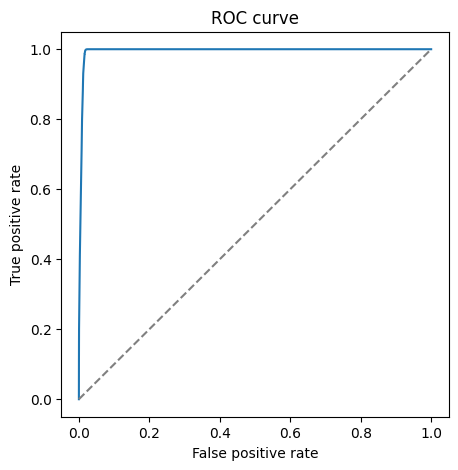

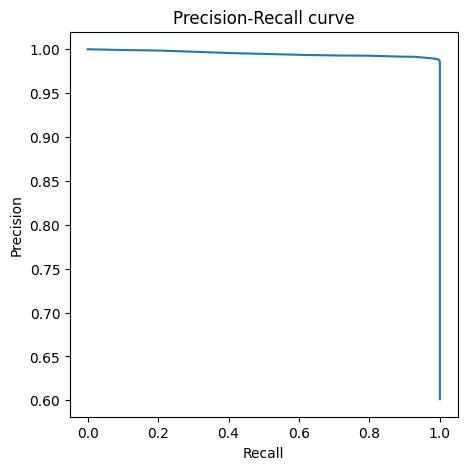

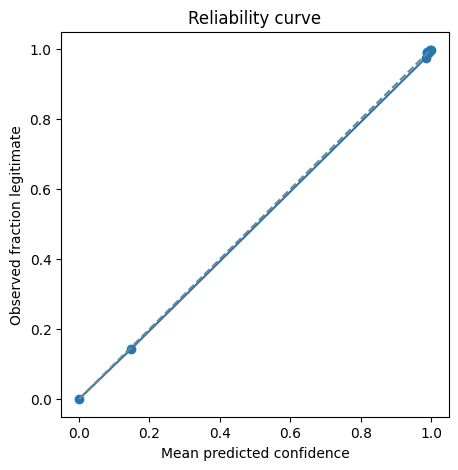

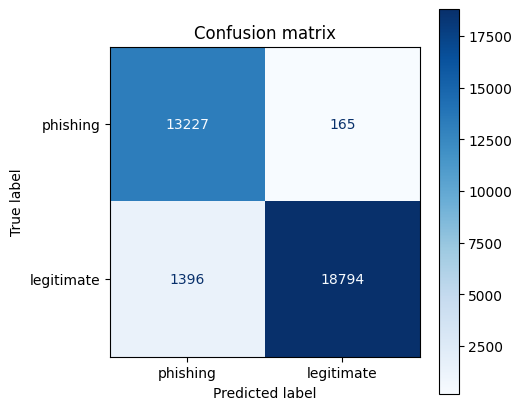

In [88]:
fpr_t, tpr_t, _ = roc_curve(y_test, test_scores)
plt.figure(figsize=(5,5)); plt.plot(fpr_t, tpr_t); plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("ROC curve")
plt.show()

prec, rec, _ = precision_recall_curve(y_test, test_scores)
plt.figure(figsize=(5,5)); plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curve")
plt.show()

frac_pos, mean_pred = calibration_curve(y_test, test_scores, n_bins=15, strategy="quantile")
plt.figure(figsize=(5,5)); plt.plot(mean_pred, frac_pos, 'o-'); plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("Mean predicted confidence"); plt.ylabel("Observed fraction legitimate"); plt.title("Reliability curve")
plt.show()

fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=["phishing","legitimate"], ax=ax, cmap="Blues")
plt.title("Confusion matrix"); plt.show()

In [89]:
correct = 0
for u in test_urls:
    result = predict_url_combined(u)
    print(u, "->", result)
    if result["label"] == "legitimate":
        correct += 1

print(f"\nFinal model stress test: {correct}/{len(test_urls)} correct (lexical-only model got 3/7)")

https://en.wikipedia.org/wiki/Machine_learning -> {'label': 'phishing', 'confidence': 0.7}
https://github.com/scikit-learn/scikit-learn -> {'label': 'phishing', 'confidence': 0.9992}
https://docs.python.org/3/library/json.html -> {'label': 'phishing', 'confidence': 1.0}
https://stackoverflow.com/questions/tagged/python -> {'label': 'phishing', 'confidence': 1.0}
https://www.nytimes.com/section/technology -> {'label': 'legitimate', 'confidence': 0.9944}
https://www.amazon.com/dp/B08N5WRWNW -> {'label': 'phishing', 'confidence': 0.2226}
https://www.google.com/search?q=phishing+detection -> {'label': 'phishing', 'confidence': 0.95}

Final model stress test: 1/7 correct (lexical-only model got 3/7)


## Limitations
- Dataset bias: every legitimate URL in this dataset is a bare 'https://www.' homepage. Restricting features to the domain removes the "has a path" shortcut, but 'is_https' (100% for legitimate URLs), 'num_subdomains' (the 'www.', counts as a subdomain) and the n-grams (which include 'www.') can still act as shortcuts. the test-set scores are tehrefore likely higher than real-world performance.

- Real world check: On 7 real legitimate URLs, the lexical-only model got 3/7 correct and the final deployed model got 1/7.

- Threshold: Legitimate is the positive class, so the 1% FPR target caps the share of phising URLs let through as legitimate (1.2% on test). The share of real users blocked is 6.9% on test.

- Unused feature: 'has_port' is always 0 because 'tldextract' removes the port from the domain.